In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from numpy.linalg import eig
import pandas as pd

In [2]:
path = f'D:/ML_Diffusion/dual_cat/c2c6_74h2o/'
rep=0
natoms=850
nsheet=574
cat1='C2'
ncat1=19
cat2='C6'
ncat2=31
n1_indx=nsheet
n2_indx=nsheet+ncat1
nsteps=5001
bx=30.396
by= 13.392
bz=15

In [3]:
def oh_dat(nsteps, oh_id_file):
    indx=np.zeros(nsteps)

    with open(path + oh_id_file, 'r') as oh:
        xyz= oh.readlines()
        for i in range(nsteps):
            indx[i]=int(xyz[i].split()[1])

    return(indx)

In [4]:
def move_to_box(x, y, z, bx, by, bz):
    # insert x, y, z coordinates as 1D arrays and move atoms into the box
    if (x)>bx/2:
        dx= int((abs(x)-bx/2)/bx)+1
        x_new=float(x-(dx*bx))
    if (x)<-bx/2:
        dx= int((abs(x)-bx/2)/bx)+1
        x_new=float(x+ (dx*bx))
    if -bx/2<=x<=bx/2:
        x_new=x
    if (y)>by/2:
        dy= int((abs(y)-by/2)/by)+1
        y_new=float(y- (dy*by))
    if (y)<-by/2:
        dy= int((abs(y)-by/2)/by)+1
        y_new=float(y+ (dy*by))
    if -by/2<=y<=by/2:
        y_new=y
        
    if (z)>bz/2:
        dz= int((abs(z)-bz/2)/bz)+1
        z_new=float(z- (dz*bz))
    if (z)<-bz/2:
        dz= int((abs(z)-bz/2)/bz)+1
        z_new=float(z (dz*bz))
    if -bz/2<=z<=bz/2:
        z_new=z
    return(x_new, y_new, z_new)
        

In [5]:
def dist(ox, oy, oz, nx, ny, nz, bx, by, bz):
    distx=(min(abs(ox-nx), abs(ox-(nx+bx)), abs(ox-(nx-bx))))
    disty=(min(abs(oy-ny), abs(oy-(ny+by)), abs(oy-(ny-by))))
    #distz=(min(abs(oz-nz), abs(oz-(nz+bz)), abs(oz-(nz-bz))))
    distz=abs(oz-nz)
    dist = np.sqrt(distx**2 + disty**2 + distz**2)
    return(distx, disty, distz, dist)


In [6]:
indx1= oh_dat(nsteps, f'oh1.{rep}_id.dat' )
indx2= oh_dat(nsteps, f'oh2.{rep}_id.dat' )

In [7]:
dist_no = pd.DataFrame(columns=['nstep', 
                                'rx_o1n1', 'ry_o1n1', 'rz_o1n1', 'r_o1n1',
                                'rx_o2n2', 'ry_o2n2', 'rz_o2n2', 'r_o2n2',
                                'rx_o2n1', 'ry_o2n1', 'rz_o2n1', 'r_o2n1',
                                'rx_o1n2', 'ry_o1n2', 'rz_o1n2', 'r_o1n2',])

with open(path +'geo_end.xyz', 'r') as out_file:
    xyz= out_file.readlines()
    for i in range(nsteps):
        end = (i+1)*(natoms+2)
        start= end - natoms
        o1_indx=int(indx1[i])
        o2_indx=int(indx2[i])

        o1_x= float(xyz[start+o1_indx-1].split()[1])
        o1_y= float(xyz[start+o1_indx-1].split()[2])
        o1_z= float(xyz[start+o1_indx-1].split()[3]) 

        o2_x= float(xyz[start+o2_indx-1].split()[1])
        o2_y= float(xyz[start+o2_indx-1].split()[2])
        o2_z= float(xyz[start+o2_indx-1].split()[3])
        
        n1_x= float(xyz[start+n1_indx].split()[1])
        n1_y= float(xyz[start+n1_indx].split()[2])
        n1_z= float(xyz[start+n1_indx].split()[3])


        n2_x= float(xyz[start+n2_indx].split()[1])
        n2_y= float(xyz[start+n2_indx].split()[2])
        n2_z= float(xyz[start+n2_indx].split()[3])


        dist_no.loc[i,"nstep"]=i
        #dist_n1_o1
        dist_no.loc[i,"rx_o1n1"], dist_no.loc[i,"ry_o1n1"], dist_no.loc[i,"rz_o1n1"], dist_no.loc[i,"r_o1n1"]=dist(o1_x, o1_y, o1_z, n1_x, n1_y, n1_z, bx, by, bz)

        # #dist_n2_o2
        dist_no.loc[i,"rx_o2n2"], dist_no.loc[i,"ry_o2n2"], dist_no.loc[i,"rz_o2n2"], dist_no.loc[i,"r_o2n2"]=dist(o2_x, o2_y, o2_z, n2_x, n2_y, n2_z, bx, by, bz)


        # #dist_n1_o2
        dist_no.loc[i,"rx_o2n1"], dist_no.loc[i,"ry_o2n1"], dist_no.loc[i,"rz_o2n1"], dist_no.loc[i,"r_o2n1"]=dist(o2_x, o2_y, o2_z, n1_x, n1_y, n1_z, bx, by, bz)
  

        # #dist_n2_o1
        dist_no.loc[i,"rx_o1n2"], dist_no.loc[i,"ry_o1n2"], dist_no.loc[i,"rz_o1n2"], dist_no.loc[i,"r_o1n2"]=dist(o1_x, o1_y, o1_z, n2_x, n2_y, n2_z, bx, by, bz)



dist_no.to_csv(path+f"dist_no_{rep}.csv", index=False)
        

In [8]:
dist_no

,nstep,rx_o1n1,ry_o1n1,rz_o1n1,r_o1n1,rx_o2n2,ry_o2n2,rz_o2n2,r_o2n2,rx_o2n1,ry_o2n1,rz_o2n1,r_o2n1,rx_o1n2,ry_o1n2,rz_o1n2,r_o1n2
0,0,4.870158,5.007242,1.155159,7.079923,0.656643,6.261964,0.13146,6.29767,7.228506,5.040448,3.862031,9.621471,12.755307,3.785726,2.838332,13.604621
1,1,4.838715,5.057878,1.107462,7.086731,0.718583,6.375036,0.093389,6.416087,7.218747,5.011693,3.880803,9.606665,12.776045,3.694535,2.866729,13.604965
2,2,4.796341,5.154645,1.046976,7.118385,0.742147,6.373362,0.07878,6.41691,7.183416,4.946809,3.908598,9.557694,12.721904,3.728092,2.940402,13.579082
3,3,4.788952,5.148308,0.981874,7.099522,0.787229,6.337252,0.051401,6.386168,7.096977,4.96568,3.913917,9.504936,12.673158,3.776735,2.983444,13.556313
4,4,4.657345,5.147214,0.828019,6.990729,0.838955,6.36274,0.033231,6.417898,7.153518,4.909383,3.803614,9.473243,12.649818,3.693857,3.008827,13.517231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,4996,0.821094,0.413115,6.044718,6.114202,2.185766,11.967559,2.607489,12.441826,6.414718,10.544035,0.915218,12.3759,9.421578,1.836638,2.52201,9.924711
4997,4997,0.842406,0.369116,6.110109,6.178942,2.256191,11.99172,2.644312,12.485357,6.27834,10.524023,1.019015,12.296789,9.376937,1.836813,2.446782,9.863447
4998,4998,0.843014,0.430023,6.141135,6.213625,2.343902,11.974155,2.675252,12.491246,6.174556,10.567759,1.067998,12.285898,9.361472,1.836419,2.397885,9.836638
4999,4999,0.845087,0.513976,6.106151,6.185744,2.488121,11.966041,2.679471,12.512251,6.09252,10.611363,1.022437,12.278648,9.425728,1.868654,2.404243,9.905383


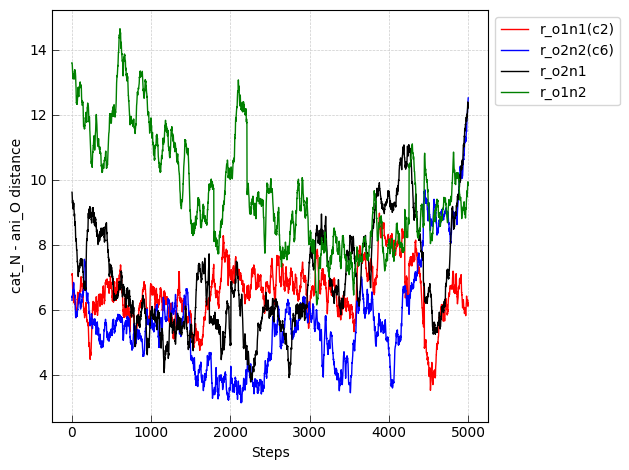

In [9]:
plt.figure()
plt.plot(dist_no["nstep"], dist_no["r_o1n1"],color='red',linewidth=1,label="r_o1n1(c2)")
plt.plot(dist_no["nstep"], dist_no["r_o2n2"],color='blue',linewidth=1,label="r_o2n2(c6)")
plt.plot(dist_no["nstep"], dist_no["r_o2n1"],color='black',linewidth=1,label="r_o2n1")
plt.plot(dist_no["nstep"], dist_no["r_o1n2"],color='green',linewidth=1,label="r_o1n2")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel('Steps')
plt.ylabel('cat_N - ani_O distance')
#plt.title("Distance between N of Cations and O of anions")
plt.tick_params(axis="x",which='major', direction="in", length=5, width=0.5)
plt.tick_params(axis="y",which='major',direction="in", length=5, width=0.5)
plt.tick_params(axis="x",which='minor', direction="in", length=5, width=0.5)
plt.tick_params(axis="y",which='minor',direction="in", length=5, width=0.5)
plt.grid(which='major',color='#CCCCCC', linestyle='--', linewidth=0.5)
#plt.ticklabel_format(axis="x", style="plain", scilimits=(0,0),useMathText=True)
#plt.ylim([0,80])
#plt.tick_params(bottom=True, top=True, left=True, right=True)
plt.tight_layout() 
#plt.savefig(path +f'dist_cat_oh_{rep}.jpg', dpi=100) 